In [19]:
from sklearn.feature_extraction.text import CountVectorizer

import pandas as pd
import numpy as np

from scipy.spatial.distance import euclidean

In [20]:
# Sample reviews
reviews = [
    "Great product, very useful and affordable ABC", 
    "Poor quality, not worth the price",
    "Excellent quality and fast delivery",
    "Not satisfied, product broke in a week",
    "Very affordable and good for daily use"
    "A Can't open the log file: '/var/log/mysql/mysql.log' (Errcode: 13)"
]

In [21]:
# Initialize the vectorizer
vectorizer = CountVectorizer()

In [22]:
vectorizer.fit(reviews)

CountVectorizer()

In [23]:
vectorizer.get_feature_names_out()

array(['13', 'abc', 'affordable', 'and', 'broke', 'can', 'daily',
       'delivery', 'errcode', 'excellent', 'fast', 'file', 'for', 'good',
       'great', 'in', 'log', 'mysql', 'not', 'open', 'poor', 'price',
       'product', 'quality', 'satisfied', 'the', 'usea', 'useful', 'var',
       'very', 'week', 'worth'], dtype=object)

In [24]:
len(vectorizer.get_feature_names_out())

32

In [25]:
rev_transformed = vectorizer.transform(reviews)

In [26]:
rev_transformed

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 40 stored elements and shape (5, 32)>

In [27]:
rev_transformed.toarray()

array([[0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
        1, 0, 0, 0, 0, 1, 0, 1, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
        0, 1, 0, 1, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
        1, 0, 1, 0, 0, 0, 0, 0, 1, 0],
       [1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 3, 2, 0, 1, 0, 0,
        0, 0, 0, 1, 1, 0, 1, 1, 0, 0]])

#### use of count vectors

In [28]:
#!pip install wikipedia

In [29]:
import wikipedia

In [30]:
topic1 = 'Generative AI'
topic2 = 'Artifical Intelligence'
topic3 = 'Agentic AI'
topic4 = 'Baseball'

q1 = wikipedia.page(topic1, auto_suggest=False)
q2 = wikipedia.page(topic2)
q3 = wikipedia.page(topic3)
q4 = wikipedia.page(topic4)

In [54]:
print("the size of ", topic1 , " is = ", len(q1.content.split()))
print("the size of ", topic2 , " is = ", len(q2.content.split()))
print("the size of ", topic3 , " is = ", len(q3.content.split()))
print("the size of ", topic4 , " is = ", len(q4.content.split()))

the size of  Generative AI  is =  5897
the size of  Artifical Intelligence  is =  13682
the size of  Agentic AI  is =  332
the size of  Baseball  is =  9852


In [32]:
cv = CountVectorizer()

In [ ]:
cv = cv.fit(([q1.content, 
              q2.content, 
              q3.content, 
              q4.content]))

len(cv.get_feature_names_out())


array(['000', '0002', '01', ..., 'zoophilia', 'čapek', 'šarūnas'],
      dtype=object)

In [49]:
# all tokens
cv.get_feature_names_out()

array(['000', '0002', '01', ..., 'zoophilia', 'čapek', 'šarūnas'],
      dtype=object)

In [50]:
# convert all the topics to vectors
X = cv.transform([q1.content, 
                  q2.content, 
                  q3.content, 
                  q4.content]).toarray()

In [51]:
X

array([[3, 0, 0, ..., 1, 0, 0],
       [2, 1, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 1]])

#### Euclidean distance

**Explanation**
1. $(x-y) \rightarrow$ element-wise difference between vectors.
2. $(x-y)^2 \rightarrow$ square each difference.
3. `np.sum(...)` $\rightarrow$ sum all squared differences.
4. `np.sqrt(...)` $\rightarrow$ square root of the sum $=$ `Euclidean distance.`

Formula:

$$
d(x, y)=\sqrt{\sum_{i=1}^n\left(x_i-y_i\right)^2}
$$

In [37]:
def euclidean_distance(x, y):   
    return np.sqrt(np.sum((x - y) ** 2))

In [38]:
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])

# Alternative 1: Using custom function
print("Custom formula  :",euclidean_distance(a, b))

# Alternative 2: Using NumPy norm
print("NumPy norm      :", np.linalg.norm(a - b))  # ~5.196

# Alternative 3: Using SciPy 
print("SciPy euclidean :", euclidean(a, b))  # ~5.196

Custom formula  : 5.196152422706632
NumPy norm      : 5.196152422706632
SciPy euclidean : 5.196152422706632


**Geometric Intuition**

- 1D: distance is just absolute difference (like on a number line).
- 2D: straight-line distance between two points on a plane.
- 3D: shortest straight line through space (like between two cities if you dig a tunnel).
- nD: same idea, even though we can’t visualize beyond 3D.

**The Core Idea**

- Between any two points, there are many possible paths.
- You could walk in zigzags, curves, or go around obstacles.
- But among all possible paths, the straight line is always the one with the least length.
- That’s why we call it the shortest distance.

**Example - illustration**

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

Euclidean distance (shortest): 5.830951894845301
Manhattan distance (zigzag): 8


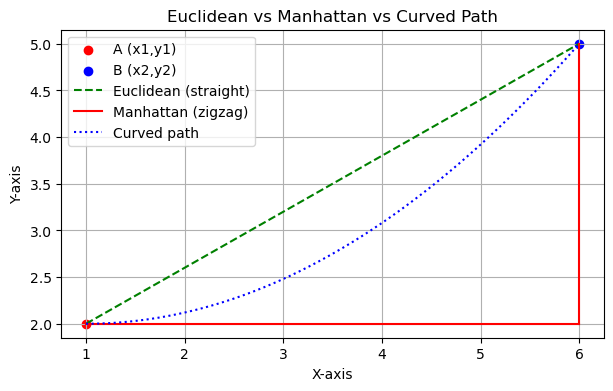

In [40]:
# Two points A and B
A = np.array([1, 2])
B = np.array([6, 5])

# Euclidean distance (straight line)
euclidean_dist = np.sqrt((B[0]-A[0])**2 + (B[1]-A[1])**2)

# Manhattan distance (zigzag: horizontal + vertical)
manhattan_dist = abs(B[0]-A[0]) + abs(B[1]-A[1])

print("Euclidean distance (shortest):", euclidean_dist)
print("Manhattan distance (zigzag):", manhattan_dist)

# ---- Visualization ----
plt.figure(figsize=(7,4))

# Plot points
plt.scatter(*A, color="red", label="A (x1,y1)")
plt.scatter(*B, color="blue", label="B (x2,y2)")

# Euclidean (straight line)
plt.plot([A[0], B[0]], [A[1], B[1]], 'g--', label="Euclidean (straight)")

# Manhattan (zigzag: A -> (x2,y1) -> B)
C = np.array([B[0], A[1]])  # corner point
plt.plot([A[0], C[0]], [A[1], C[1]], 'r-', label="Manhattan (zigzag)")
plt.plot([C[0], B[0]], [C[1], B[1]], 'r-')

# An extra curved path (just for illustration, longer)
t = np.linspace(0, 1, 100)
curve_x = A[0] + (B[0]-A[0])*t
curve_y = A[1] + (B[1]-A[1])*t**2  # quadratic curve
plt.plot(curve_x, curve_y, 'b:', label="Curved path")

# Labels and formatting
plt.legend()
plt.grid(True)
plt.title("Euclidean vs Manhattan vs Curved Path")
plt.xlabel("X-axis")
plt.ylabel("Y-axis")
plt.show()

In [41]:
# --- Passages ---
p1 = "Artificial intelligence is transforming healthcare and improving patient care."
p2 = "Artificial intelligence is revolutionizing healthcare and enhancing patient care."
p3 = "Climate change impacts agriculture, ecosystems, and global food security."
p4 = "Machine learning and AI are advancing diagnostics in modern hospitals."
p5 = "Global warming threatens biodiversity and disrupts natural ecosystems."

docs = [p1, p2, p3, p4, p5]

In [42]:
# --- Count Vectorization ---
test_vect = CountVectorizer()
test_X    = test_vect.fit_transform(docs).toarray()

print("Feature Names:", test_vect.get_feature_names_out())
print("Count Vectors:\n", test_X)

Feature Names: ['advancing' 'agriculture' 'ai' 'and' 'are' 'artificial' 'biodiversity'
 'care' 'change' 'climate' 'diagnostics' 'disrupts' 'ecosystems'
 'enhancing' 'food' 'global' 'healthcare' 'hospitals' 'impacts'
 'improving' 'in' 'intelligence' 'is' 'learning' 'machine' 'modern'
 'natural' 'patient' 'revolutionizing' 'security' 'threatens'
 'transforming' 'warming']
Count Vectors:
 [[0 0 0 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 1 0 0 0 0 1 0 0 0 1 0]
 [0 0 0 1 0 1 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 0 0 1 1 0 0 0 0]
 [0 1 0 1 0 0 0 0 1 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0]
 [1 0 1 1 1 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1]]


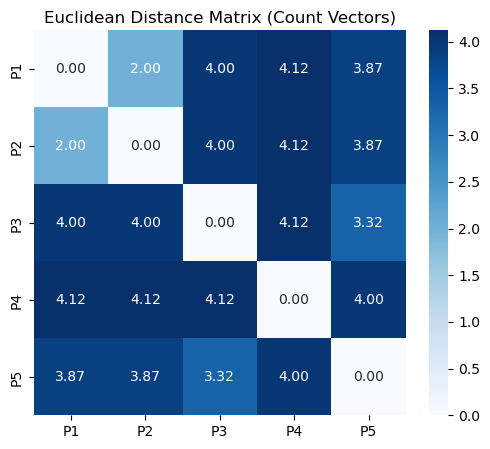

In [43]:
# Build Euclidean distance matrix
n = len(docs)
dist_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        dist_matrix[i, j] = euclidean(test_X[i], test_X[j])  # use distance.euclidean

# --- Heatmap visualization ---
plt.figure(figsize=(6, 5))
sns.heatmap(dist_matrix, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=[f"P{i+1}" for i in range(n)],
            yticklabels=[f"P{i+1}" for i in range(n)])
plt.title("Euclidean Distance Matrix (Count Vectors)")
plt.show()

This will give you a 5×5 heatmap where:

- P1 & P2 are closest (low distance).
- P3 & P5 are somewhat related.
- P4 sits between P1/P2 and the others.

... back to the code

In [44]:
print(topic1, "vs.", topic1, euclidean_distance(X[0], X[0]))
print(topic1, "vs.", topic2, euclidean_distance(X[0], X[1]))
print(topic1, "vs.", topic3, euclidean_distance(X[0], X[2]))
print(topic1, "vs.", topic4, euclidean_distance(X[0], X[3]))

Generative AI vs. Generative AI 0.0
Generative AI vs. Artifical Intelligence 730.2177757354309
Generative AI vs. Agentic AI 468.63098489109746
Generative AI vs. Baseball 754.7926867690227


#### Cosine Sim

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

In [46]:
# Compute cosine similarity matrix
cosine_sim_matrix = cosine_similarity(X)

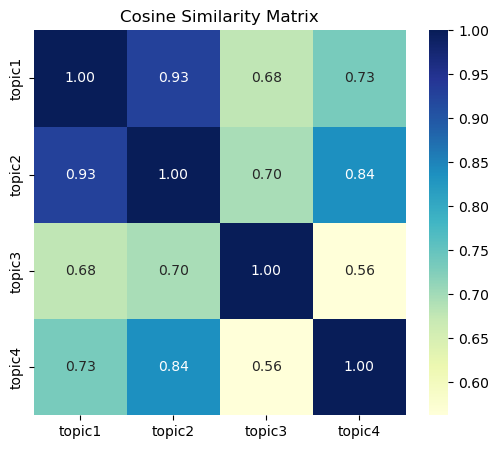

In [47]:
# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cosine_sim_matrix, annot=True, fmt=".2f", cmap="YlGnBu",
            xticklabels=["topic1", "topic2", "topic3", "topic4"], 
            yticklabels=["topic1", "topic2", "topic3", "topic4"])
plt.title("Cosine Similarity Matrix")
plt.show()

In [48]:
# Example pairwise similarities
print(topic1, "vs.", topic1, cosine_sim_matrix[0, 0])
print(topic1, "vs.", topic2, cosine_sim_matrix[0, 1])
print(topic1, "vs.", topic3, cosine_sim_matrix[0, 2])
print(topic1, "vs.", topic4, cosine_sim_matrix[0, 3])

Generative AI vs. Generative AI 1.0000000000000004
Generative AI vs. Artifical Intelligence 0.9281814307508643
Generative AI vs. Agentic AI 0.6773347364958227
Generative AI vs. Baseball 0.7319173491986631


---
#### Comparing

```python
Generative AI vs. Generative AI → 0.0   (identical, no distance)
Generative AI vs. Artificial Intelligence → 2.0
Generative AI vs. Agentic AI → 4.0
Generative AI vs. Baseball → 4.1231

Generative AI vs. Generative AI → 1.00
Generative AI vs. Artificial Intelligence → 0.93
Generative AI vs. Agentic AI → 0.81
Generative AI vs. Baseball → 0.74
```

👉 Here, "Artificial Intelligence" is closer (2.0) than "Agentic AI" (4.0).
But since Euclidean doesn’t normalize vector length, longer/wordier sentences can appear farther away even if semantically close.

⚖️ When to use which?

- Euclidean distance → works better when magnitudes matter (e.g., embeddings of fixed length, clustering numeric features).

- Cosine similarity → better for text embeddings, since it focuses on meaning (direction of vectors) rather than length.